# Часть 1. SVM, LR и калибровка вероятностей (2 балла + 0.5 бонус)

In [ ]:
import numpy as np
import pandas as pd
# import polars as pl
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
# pl.Config().set_tbl_rows(100)
# pl.Config().set_tbl_cols(100)

#### __Задание 1.1  Сравнение методов__ (0.5 балла)



Сгенерируем синтетические данные.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# фиксируем random_state для воспроизводимости результатов
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

__Случайный классификатор__

Для начала зададим самую простую модель, которая на каждом объекте выдаёт случайный ответ. По тестовой выборке вычислим AUC-ROC, AUC-PR.

In [ ]:
from sklearn.dummy import DummyClassifier
random_classifier = DummyClassifier(strategy='uniform', random_state=42).fit(X_train, y_train)
y_random = random_classifier.predict_proba(X_test)[:,1]
y_random

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5])

**Вопрос:** решаем задачу бинарной классификации, но y\_random содержит какие-то дробные числа, а не 0/1. Почему?



**Ответ**: Здесь предсказание (класс) генерируется с одинаковой вероятностью. В y_random лежат как раз эти вероятности (тк метод predict_proba возвращает вероятности для каждого класса), а не метки классов, поэтому он содержит дробные числа (а именно массив из 0.5).

*Ниже приведен **пример** работы* со встроенными функциями `sklearn` для отрисовки ROC и PR кривых, сохранения метрик. Пайплайн можно изменять как вам удобно.

In [ ]:
from sklearn.metrics import average_precision_score

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

Random Classifier metrics
AUC-PR: 0.5057
AUC-ROC: 0.5000


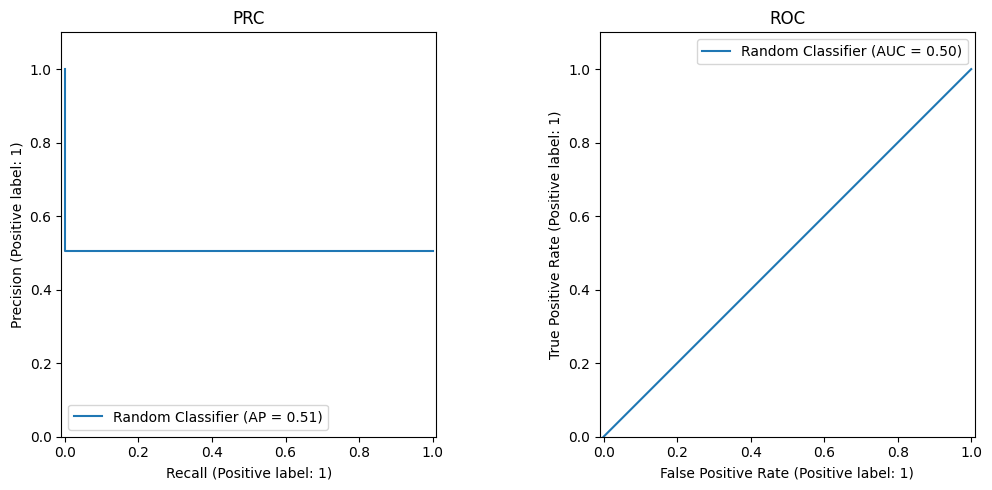

In [ ]:
def depict_pr_roc(y_true, y_pred, classifier_name='Some Classifier', ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(11, 5))

    print(classifier_name, 'metrics')
    PrecisionRecallDisplay.from_predictions(y_true, y_pred, ax=ax[0], name=classifier_name)
    print('AUC-PR: %.4f' % average_precision_score(y_true, y_pred))
    ax[0].set_title("PRC")
    ax[0].set_ylim(0, 1.1)

    RocCurveDisplay.from_predictions(y_true, y_pred, ax=ax[1], name=classifier_name)
    print('AUC-ROC: %.4f' % roc_auc_score(y_true, y_pred))
    ax[1].set_title("ROC")
    ax[1].set_ylim(0, 1.1)

    plt.tight_layout()
    plt.legend()


depict_pr_roc(y_test, y_random, 'Random Classifier')

In [ ]:
# dataframe для сравнения
# методов классификации по метрикам
df_metrics = pd.DataFrame(
    columns=['auc_pr', 'roc_auc_score', 'reg_const']
)
precision, recall, _ = precision_recall_curve(y_test, y_random)
# добавление очередной строки с характеристиками метода
df_metrics.loc['Random Classifier'] = [
      average_precision_score(y_test, y_random),
      roc_auc_score(y_test, y_random),
      0,
]

# по аналогии результаты следующих экспериментов можно будет собрать в табличку
df_metrics

,auc_pr,roc_auc_score,reg_const
Random Classifier,0.505667,0.5,0.0


__Support Vector Machine (Linear Kernel)__

Обучите метод опорных векторов.

Подберите параметр регуляризации `C` с точки зрения AUC-PR (можете воспользоваться кросс-валидацией или отделить валидационную выборку от обучающей).


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

svc = LinearSVC()
params = {'C': np.logspace(-5, 2, 100)}
clf = GridSearchCV(svc, params, cv=5, scoring='average_precision')
clf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearSVC(),
             param_grid={'C': array([1.00000000e-05, 1.17681195e-05, 1.38488637e-05, 1.62975083e-05,
       1.91791026e-05, 2.25701972e-05, 2.65608778e-05, 3.12571585e-05,
       3.67837977e-05, 4.32876128e-05, 5.09413801e-05, 5.99484250e-05,
       7.05480231e-05, 8.30217568e-05, 9.77009957e-05, 1.14975700e-04,
       1.35304777e-04, 1.59228279e-04, 1.87381742e-04, 2....
       2.36448941e+00, 2.78255940e+00, 3.27454916e+00, 3.85352859e+00,
       4.53487851e+00, 5.33669923e+00, 6.28029144e+00, 7.39072203e+00,
       8.69749003e+00, 1.02353102e+01, 1.20450354e+01, 1.41747416e+01,
       1.66810054e+01, 1.96304065e+01, 2.31012970e+01, 2.71858824e+01,
       3.19926714e+01, 3.76493581e+01, 4.43062146e+01, 5.21400829e+01,
       6.13590727e+01, 7.22080902e+01, 8.49753436e+01, 1.00000000e+02])},
             scoring='average_precision')

In [ ]:
best_C = clf.best_params_['C']

In [ ]:
lin_svc = LinearSVC(C=best_C)
lin_svc.fit(X_train, y_train)
y_pred_svc = lin_svc.decision_function(X_test)

  На тестовой части:
  - постройте ROC и PR кривые,
  - посчитайте AUC-ROC, AUC-PR

LinearSVC metrics
AUC-PR: 0.8319
AUC-ROC: 0.8407


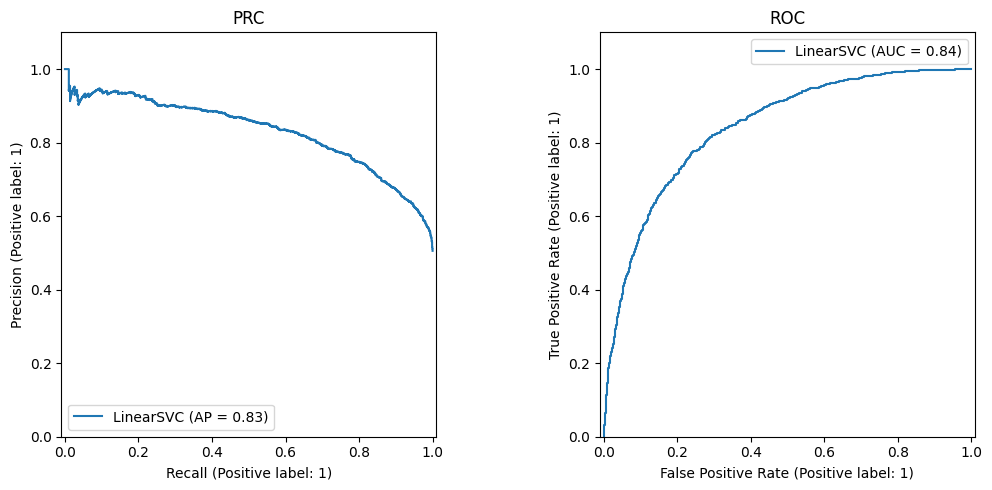

In [ ]:
depict_pr_roc(y_test, y_pred_svc, 'LinearSVC')

Проанализируйте, как себя ведут обе кривые:
- Что происходит при увеличении порога? Как бы вы это проинтерпретировали?
- Монотонные ли кривые? Как вы это объясните?

ROC curve: при увеличении порога снижается кол-во классифицированных как положительных моделью объектов, поэтому снижается TPR (он же recall), так как мы охватываем меньше (или столько же) объектов с положительным классом. FPR также уменьшается, так как меньше (или столько же) объектов будет ошибочно классифицировано как положительные. Тут как бы показывается компромисс между TPR и FPR. Кривая монотонна, так как при снижении порога (то есть при движении вдоль кривой вправо) TPR и FPR не могут упасть (если следующий объект после изменения порога реально положительный, то FPR не меняется, а TPR увеличивается, иначе наоборот)

PR curve: при увеличении порога recall снижается (TPR в ROC), а precision может как падать, так и расти, тк могут снижаться и FP, и TP, но если модель хорошая и данные адекватные, то с увеличением порога модель должна быть более уверена в положительно классифицируемых объектах, и тогда FP снижается, а precision растет. PR кривая показывает компромисс между точностью и полнотой. Данная кривая не обязательно монотонна (что видно и на графике выше около начала кривой), как раз из-за не обязательной монотонности точности.

Сравните AUC-ROC и AUC-PR для вашей модели с этими же метриками для случайного классификатора.

In [ ]:
df_metrics.loc['LinearSVC'] = [
      average_precision_score(y_test, y_pred_svc),
      roc_auc_score(y_test, y_pred_svc),
      best_C,
]
df_metrics

,auc_pr,roc_auc_score,reg_const
Random Classifier,0.505667,0.500000,0.000000
LinearSVC,0.831913,0.840676,0.000027


__Logistic Regression__


Аналогичное задание для логистической регрессии с L2 регуляризатором:


*   подберите гиперпараметр C, используя метрику AUC-PR
*   нарисуйте ROC, PR кривые для тестовой части
*   выведите метрики для тестовых данных и сравните их с результатами случайного классификатора



In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
params_lr = {'C': np.logspace(-5, 2, 100)}
clf_lr = GridSearchCV(lr, params_lr, cv=5, scoring='average_precision')
clf_lr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-05, 1.17681195e-05, 1.38488637e-05, 1.62975083e-05,
       1.91791026e-05, 2.25701972e-05, 2.65608778e-05, 3.12571585e-05,
       3.67837977e-05, 4.32876128e-05, 5.09413801e-05, 5.99484250e-05,
       7.05480231e-05, 8.30217568e-05, 9.77009957e-05, 1.14975700e-04,
       1.35304777e-04, 1.59228279e-04, 1.873817...
       2.36448941e+00, 2.78255940e+00, 3.27454916e+00, 3.85352859e+00,
       4.53487851e+00, 5.33669923e+00, 6.28029144e+00, 7.39072203e+00,
       8.69749003e+00, 1.02353102e+01, 1.20450354e+01, 1.41747416e+01,
       1.66810054e+01, 1.96304065e+01, 2.31012970e+01, 2.71858824e+01,
       3.19926714e+01, 3.76493581e+01, 4.43062146e+01, 5.21400829e+01,
       6.13590727e+01, 7.22080902e+01, 8.49753436e+01, 1.00000000e+02])},
             scoring='average_precision')

In [ ]:
best_C_lr = clf_lr.best_params_['C']

In [ ]:
logreg = LogisticRegression(C=best_C_lr)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict_proba(X_test)[:, 1]

Нарисуйте ROC, PR кривые для тестовой части для всех 3 классификаторов на одном графике

LogisticRegression metrics
AUC-PR: 0.8348
AUC-ROC: 0.8427


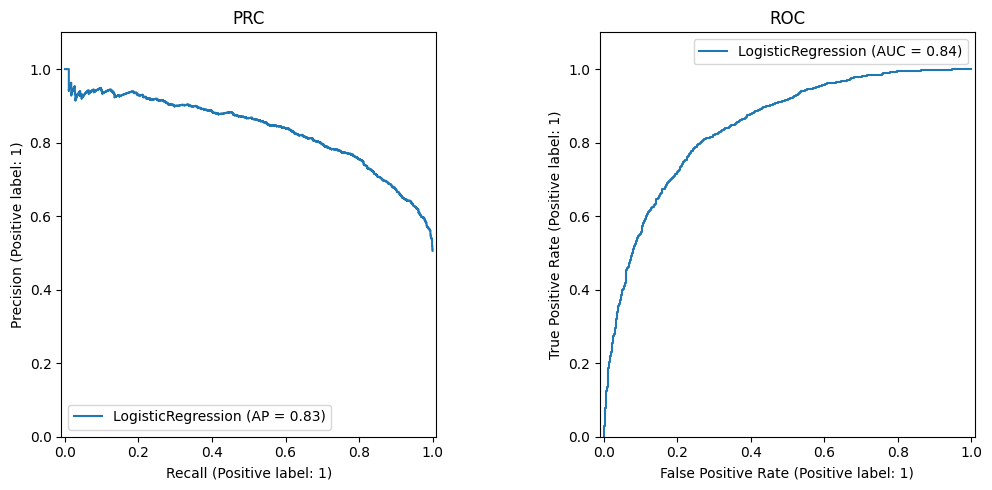

In [ ]:
depict_pr_roc(y_test, y_pred_logreg, 'LogisticRegression')

**Вопрос:** Сравните результаты LR и SVM с точки зрения всех вычисленных критериев качества, объясните различия (если они есть).



In [ ]:
df_metrics.loc['Logistic Regression'] = [
      average_precision_score(y_test, y_pred_logreg),
      roc_auc_score(y_test, y_pred_logreg),
      best_C_lr,
]
df_metrics

,auc_pr,roc_auc_score,reg_const
Random Classifier,0.505667,0.500000,0.000000
LinearSVC,0.831913,0.840676,0.000027
Logistic Regression,0.834796,0.842711,0.000423


**Ответ:** Модели показывают практически одинаковое качество, возможно, потому что нет сложной нелинейной зависимости и выбросов в данных.

#### __Задание 1.2. Визуализация в подходах SVM, LR__ (0.5 балла)



В названии метода опорных векторов присутствуют некоторые "опорные векторы". По сути, это объекты из обучающей выборки, которые задали положение разделяющей гиперплоскости.

* Сгенерируйте синтетические данные с помощью `make_classification` __с 2 признаками__, обучите на нём метод опорных векторов. Не забудьте зафиксировать seed для воспроизводимости

* Визуализируйте разделяющую прямую, все объекты и выделите опорные векторы. Ниже есть шаблоны, можете воспользоваться ими, либо написать своё

In [ ]:
X, y = make_classification(
    n_samples=5000, n_features=2, n_redundant=0, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
svc = LinearSVC()
params = {'C': np.logspace(-5, 2, 100)}
clf = GridSearchCV(svc, params, cv=5, scoring='average_precision')
clf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearSVC(),
             param_grid={'C': array([1.00000000e-05, 1.17681195e-05, 1.38488637e-05, 1.62975083e-05,
       1.91791026e-05, 2.25701972e-05, 2.65608778e-05, 3.12571585e-05,
       3.67837977e-05, 4.32876128e-05, 5.09413801e-05, 5.99484250e-05,
       7.05480231e-05, 8.30217568e-05, 9.77009957e-05, 1.14975700e-04,
       1.35304777e-04, 1.59228279e-04, 1.87381742e-04, 2....
       2.36448941e+00, 2.78255940e+00, 3.27454916e+00, 3.85352859e+00,
       4.53487851e+00, 5.33669923e+00, 6.28029144e+00, 7.39072203e+00,
       8.69749003e+00, 1.02353102e+01, 1.20450354e+01, 1.41747416e+01,
       1.66810054e+01, 1.96304065e+01, 2.31012970e+01, 2.71858824e+01,
       3.19926714e+01, 3.76493581e+01, 4.43062146e+01, 5.21400829e+01,
       6.13590727e+01, 7.22080902e+01, 8.49753436e+01, 1.00000000e+02])},
             scoring='average_precision')

In [ ]:
best_C = clf.best_params_['C']

In [ ]:
lin_svc = LinearSVC(C=best_C)
lin_svc.fit(X_train, y_train)

LinearSVC(C=4.534878508128582)

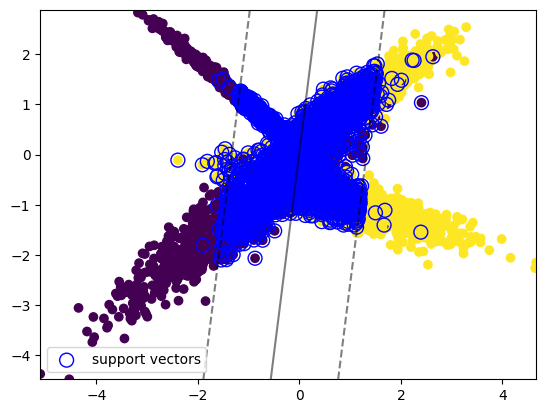

In [ ]:
def plot_svm_2D(X, y, model,  plot_support=True):

    # создали сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Ответы модели для сетки для отрисовки разделяющей прямой
    Z = model.decision_function(xy).reshape(XX.shape)

    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    # Отрисовали выборку
    plt.scatter(
        X[:, 0], X[:, 1], c=y
    )

    # Отрисовали опорные векторы
    if plot_support:

        y_pred = model.predict(X)
        sv_index = np.where((np.abs(model.decision_function(X)) <= 1) | (y != y_pred))[0]
        sv = X[sv_index]

        plt.scatter(
            sv[:, 0], sv[:, 1],
            label='support vectors',
            s=100,
            linewidth=1,
            edgecolor="blue",
            facecolors='none'
        )

    plt.legend()

plot_svm_2D(X, y, lin_svc)

**Вопрос:** какие объекты выделяются как "опорные"?



**Ответ:** опорные векторы - это те, которые сильнее всего повлияли на обучение модели (то есть те, которые лежат близко к гиперплоскости и те, которые не удалось отнести к правильному классу из-за линейной неразделимости).

В отличие от метода опорных векторов, логистическая регрессия не пытается построить разделяющую гиперплоскость с максимальным отступом, а приближает в каждой точке пространства объектов вероятность положительных ответов $p(y=+1|x)$. Попробуйте нарисовать это распределение на плоскости, не забудьте отметить на ней все объекты.

In [ ]:
lr = LogisticRegression()
params_lr = {'C': np.logspace(-5, 2, 100)}
clf_lr = GridSearchCV(lr, params_lr, cv=5, scoring='average_precision')
clf_lr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-05, 1.17681195e-05, 1.38488637e-05, 1.62975083e-05,
       1.91791026e-05, 2.25701972e-05, 2.65608778e-05, 3.12571585e-05,
       3.67837977e-05, 4.32876128e-05, 5.09413801e-05, 5.99484250e-05,
       7.05480231e-05, 8.30217568e-05, 9.77009957e-05, 1.14975700e-04,
       1.35304777e-04, 1.59228279e-04, 1.873817...
       2.36448941e+00, 2.78255940e+00, 3.27454916e+00, 3.85352859e+00,
       4.53487851e+00, 5.33669923e+00, 6.28029144e+00, 7.39072203e+00,
       8.69749003e+00, 1.02353102e+01, 1.20450354e+01, 1.41747416e+01,
       1.66810054e+01, 1.96304065e+01, 2.31012970e+01, 2.71858824e+01,
       3.19926714e+01, 3.76493581e+01, 4.43062146e+01, 5.21400829e+01,
       6.13590727e+01, 7.22080902e+01, 8.49753436e+01, 1.00000000e+02])},
             scoring='average_precision')

In [ ]:
best_C_lr = clf_lr.best_params_['C']

In [ ]:
logreg = LogisticRegression(C=best_C_lr)
logreg.fit(X_train, y_train)

LogisticRegression(C=1.0476157527896641)

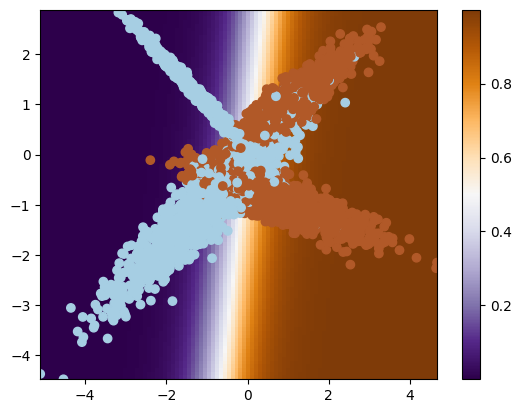

In [ ]:
def plot_logreg_2D(X, y, model):

    # создали сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Ответы модели для сетки для отрисовки распределения
    Z = model.predict_proba(xy)[:, 1]
    Z = Z.reshape((xx.shape[0], -1)).T

    image = plt.imshow(
        Z,
        interpolation='nearest',
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        aspect='auto',
        origin='lower',
        cmap=plt.cm.PuOr_r
    )

    #Отрисовали выборку
    plt.scatter(
        X[:, 0], X[:, 1],
        c=y,
        cmap=plt.cm.Paired
    )

    plt.colorbar(image)

plot_logreg_2D(X, y, logreg)

**Вопрос:** Как на картинке визуализирована область, где модель не уверена ($p(y=+1|x) = 0.5$)? Как это обосновать теоритечески?



**Ответ:** на картинке это область, подкрашенная белым цветом. Это область, где скалярное произведение равно нулю (если подставить нулевое скалярное произведение в сигмоиду, то получится значение 0.5), получается уравнение гиперплоскости, которая отделяет один класс от другого, поэтому там вероятность принадлежности к каждому из классов одинакова.

#### __Задание 2. Калибровка вероятностей__ (1 балл)



Перейдём к оценке качества выдаваемых алгоритмами вероятностей. Начнём с калибровочных кривых.

Допустим, алгоритм возвращает некоторые числа от нуля до единицы. Хорошо ли они оценивают вероятность?

Хорошо откалиброванный  классификатор должен выдавать значения так, чтобы среди образцов, для которых он дал значение, близкое к $\alpha$, примерно $\alpha * 100 \%$ фактически принадлежали к положительному классу. (Например, если классификатор выдает 0.3 для некоторых, то 30% из них должны принадлежать классу 1)

Для построения калибровочной криовой используем следующий алгоритм:

Разобьем отрезок $[0, 1]$ на несколько маленьких отрезков одинаковой длины.

Рассмотрим $i$-й отрезок с границами $[a_i, b_i]$ и предсказания $p_1, p_2, \dots, p_k$, которые попали в него. Пусть им соответствуют истинные ответы $y_1, y_2, \dots, y_k$. Если алгоритм выдает корректные вероятности, то среди этих истинных ответов должно быть примерно $(a_i + b_i) / 2$ единиц. Иными словами, если нарисовать кривую, у которой по оси X отложены центры отрезков, а по оси Y — доли единичных ответов этих в отрезках, то она должна оказаться диагональной.

Ниже приведена функция, которая должна рисовать такие кривые. В ней допущено две ошибки — найдите и исправьте их.

In [ ]:
def plot_calibration_curve(y_test, preds):
    bin_middle_points = []
    bin_real_ratios = []
    n_bins = 10
    for i in range(n_bins):
        l = 1.0 / n_bins * i
        r = 1.0 / n_bins * (i + 1)
        bin_middle_points.append((l + r) / 2) # l + r, а не l - r
        bin_real_ratios.append(np.mean(y_test[(preds >= l) & (preds < r)] == 1)) # np.mean, а не np.min
    plt.figure(figsize=(6,6))
    plt.plot(bin_middle_points, bin_real_ratios)
    plt.ylim([-0.05, 1.05])
    plt.grid()

Сгенерируйте синтетические данные аналогично использованным в самом первом задании. Постройте калибровочные кривые на тестовой части для логистической регрессии и метода опорных векторов (не забудьте перевести его предсказания в $[0;1]$).

Отрисуйте калибровочную кривую идеально откалиброванной модели (диагональ)

In [ ]:
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
svc = LinearSVC()
params = {'C': np.logspace(-5, 2, 100)}
clf = GridSearchCV(svc, params, cv=5, scoring='average_precision')
clf.fit(X_train, y_train)
best_C = clf.best_params_['C']

In [ ]:
lin_svc = LinearSVC(C=best_C)
lin_svc.fit(X_train, y_train)
pred_proba_svc = 1 / (1 + np.exp(-lin_svc.decision_function(X_test)))

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


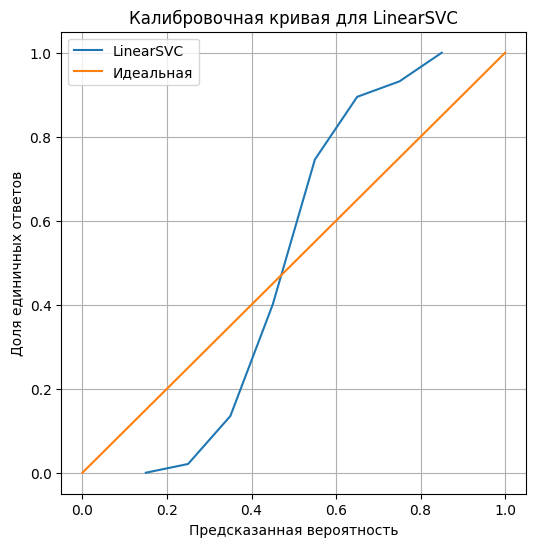

In [ ]:
plot_calibration_curve(y_test, pred_proba_svc)
plt.title('Калибровочная кривая для LinearSVC')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Доля единичных ответов')
plt.plot(np.linspace(0, 1, 10), np.linspace(0, 1, 10))
plt.legend(['LinearSVC', 'Идеальная']);

In [ ]:
lr = LogisticRegression()
params_lr = {'C': np.logspace(-5, 2, 100)}
clf_lr = GridSearchCV(lr, params_lr, cv=5, scoring='average_precision')
clf_lr.fit(X_train, y_train)
best_C_lr = clf_lr.best_params_['C']

In [ ]:
logreg = LogisticRegression(C=best_C_lr)
logreg.fit(X_train, y_train)
pred_proba_lr = logreg.predict_proba(X_test)[:, 1]

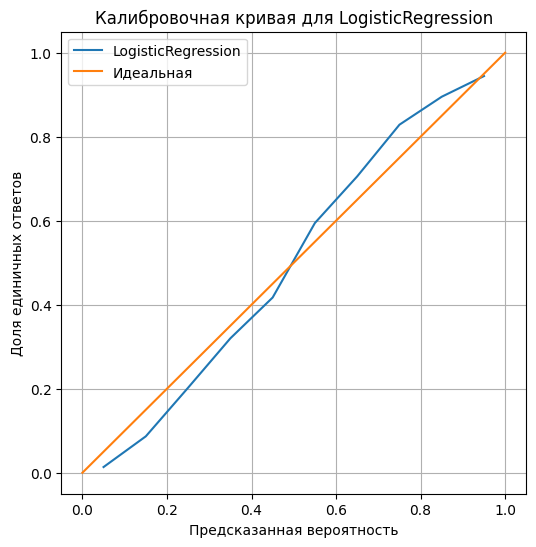

In [ ]:
plot_calibration_curve(y_test, pred_proba_lr)
plt.title('Калибровочная кривая для LogisticRegression')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Доля единичных ответов')
plt.plot(np.linspace(0, 1, 10), np.linspace(0, 1, 10))
plt.legend(['LogisticRegression', 'Идеальная']);

**Вопрос**: хорошо ли откалиброваны кривые для SVM, логистической регрессии? Подумайте, как это следует из вида кривой

**Ответ:** чем ближе кривая к кривой идеально откалиброванной модели (это диагональ y=x, где средние предсказанные вероятности совпадают с долей положительных объектов среди объектов с примерно одной вероятностью). Из графиков можно сделать вывод, что SVM хуже откалиброванна, чем логистическая регрессия, так как первая кривая расположена дальше от иделаьной, чем вторая. Логистическая регрессия очень близка к идеально откалиброванной модели, в то время как SVM в целом делает нелохие предсказания, тк при небольших вероятностях объекты имеют отрицательный класс и наоборот, но модель как будто забивает на вероятности, и, если в задаче необходимо работать с вероятностями, то на выходы Linear SVC смотреть не стоит.

Из формальных способов в этом убедиться есть знакомый вам LogLoss, который напрямую оценивает вероятности,
$$\text{LogLoss} = -\frac{1}{N}\sum_{i} \sum_{k \in {0. 1}}\log p_k[y_i = k]$$
а так же BrierScore, который подсчитывает отклонение между получившейся вероятностью и реальным значением таргета.
$$\text{BrierScore} = \frac{1}{N}\sum_{i} (p_i - y_i)^2$$
Посмотрите на них тоже и сделайте вывод

In [ ]:
def losses(pred, y_test):
    logloss = - np.mean(np.log(pred) * (y_test == 1) + np.log(1 - pred) * (y_test == 0))
    brier = np.mean((pred - y_test) ** 2)
    return logloss, brier

In [ ]:
logloss_svc, brier_svc = losses(pred_proba_svc, y_test)
logloss_lr, brier_lr = losses(pred_proba_lr, y_test)
print(f'Linear SVC:\nLogloss: {logloss_svc}, BrierScore: {brier_svc} \n')
print(f'LogisticRegression:\nLogloss: {logloss_lr}, BrierScore: {brier_lr}')

Linear SVC:
Logloss: 0.5886902029305541, BrierScore: 0.19943132121003374 

LogisticRegression:
Logloss: 0.49920474758749, BrierScore: 0.16416217985938578


У логистической регрессии лоссы меньше, чем у SVM, что подтверждает полученное на графиках.

Изучите распределение ответов классификаторов при помощи гистограмм

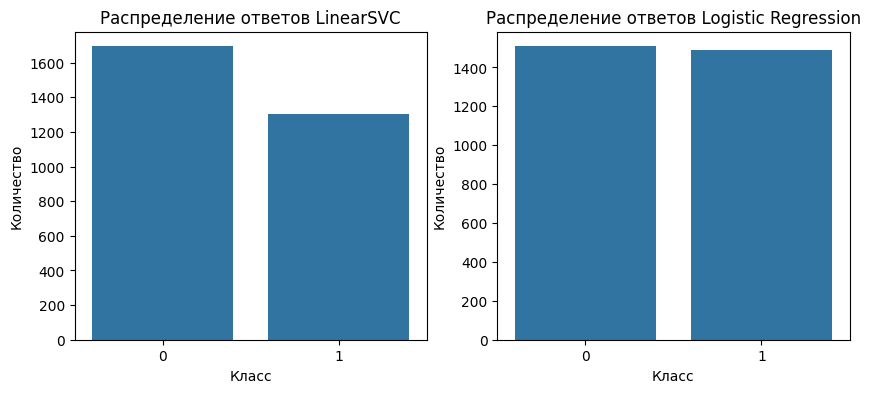

In [ ]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=2)
sns.countplot(x=lin_svc.predict(X_test), ax=ax[0])
sns.countplot(x=logreg.predict(X_test), ax=ax[1])
ax[0].set_title('Распределение ответов LinearSVC')
ax[0].set_xlabel('Класс')
ax[0].set_ylabel('Количество')
ax[1].set_title('Распределение ответов Logistic Regression')
ax[1].set_xlabel('Класс')
ax[1].set_ylabel('Количество');

**Вопрос:** Чем они различаются? Чем вы можете объяснить это?

In [ ]:
np.unique(y_test, return_counts=True)

(array([0, 1]), array([1483, 1517]))

**Ответ:** Как видно, в SVM больше предсказалось объектов отрицательного (в данном случае нулевого) класса, когда в логистической регрессии их примерно поровну (как и в распределении реальных ответов). Возможно, в SVC много объектов 1 класса попало в область, где объекты классифицируются как 0 класс, но модель старается не только как можно точнее разделить объекты на классы, но и учесть расстояния до них. Логистическая регрессия могла эти объекты "захватить", и гиперплоскость тогда получится другая.

Воспользуйтесь `CalibratedClassifierCV` из `sklearn` для калибровки вероятностей метода опорных векторов на обучении и постройте с его помощью  предсказания для тестовой выборки.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
calibrated_clf = CalibratedClassifierCV(LinearSVC(C=best_C))
calibrated_clf.fit(X_train, y_train)
pred_svc_calib = calibrated_clf.predict_proba(X_test)[:, 1]

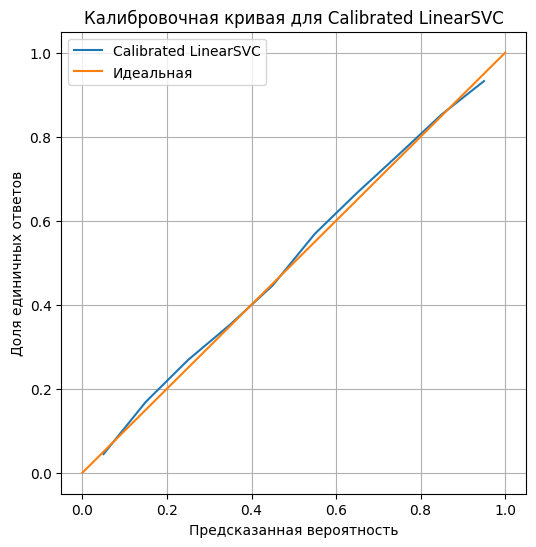

In [ ]:
plot_calibration_curve(y_test, pred_svc_calib)
plt.title('Калибровочная кривая для Calibrated LinearSVC')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Доля единичных ответов')
plt.plot(np.linspace(0, 1, 10), np.linspace(0, 1, 10))
plt.legend(['Calibrated LinearSVC', 'Идеальная']);

In [ ]:
logloss_calibsvc, brier_calibsvc = losses(pred_svc_calib, y_test)
print(f'Calibrated Linear SVC:\nLogloss: {logloss_calibsvc}, BrierScore: {brier_calibsvc} \n')

Calibrated Linear SVC:
Logloss: 0.4949807650099245, BrierScore: 0.16329174089688892 



**Вопрос:** Улучшились ли калибровочная кривая и качество калибровки?

**Ответ:** да, кривая стала ближе к идеальной, а лоссы уменьшились.

# Часть 2. Обработка категориальных переменных (4 балла + 1.5 бонус)

Как мы знаем, перекодировать категориальную переменную в список чисел (к примеру 1, 2, 3, ..., n) плохо, поскольку это бы задало на множестве ее значений некоторый порядок, не имеющий смысла.

В этой части мы рассмотрим два основных способа обработки категориальных значений:
- One-hot-кодирование
- Счётчики (CTR, mean-target кодирование, ...) — каждый категориальный признак заменяется на среднее значение целевой переменной по всем объектам, имеющим одинаковое значение в этом признаке.

Начнём с one-hot-кодирования. Допустим наш категориальный признак $f_j(x)$ принимает значения из множества $C=\{c_1, \dots, c_m\}$. Заменим его на $m$ бинарных признаков $b_1(x), \dots, b_m(x)$, каждый из которых является индикатором одного из возможных категориальных значений:
$$
b_i(x) = [f_j(x) = c_i]
$$

#### __Подготовка данных__

*(бесценный шаг)*

Разберем датасет [покупок велосипедов](https://www.kaggle.com/datasets/heeraldedhia/bike-buyers/): даны признаки покупателя, требуется предсказать, купит ли он/она велосипед



Замените пропуски в категориальных переменных на новую категорию (`'undefined'`)

Разделите признаки на 2 таблицы: категориальные и числовые признаки

In [ ]:
import kagglehub

path = kagglehub.dataset_download("heeraldedhia/bike-buyers") +  "/bike_buyers.csv"

In [ ]:
# Прочитаем датасет
df = pd.read_csv(path)
df.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


In [ ]:
# пропуски
df.isna().sum()

,0
ID,0
Marital Status,7
Gender,11
Income,6
Children,8
Education,0
Occupation,0
Home Owner,4
Cars,9
Commute Distance,0


In [ ]:
# Заменим пропуски категориальных переменных
df[['Marital Status', 'Gender', 'Home Owner']] = df[['Marital Status', 'Gender', 'Home Owner']].fillna('undefined')

# Отделим X и y
X = df.drop(columns='Purchased Bike')
y = df['Purchased Bike']


# Разделим на категориальные признаки и числовые
num = ['Income', 'Children', 'Cars', 'Age']
X_numerical = X[num]
X_categorical = X.drop(columns=num).drop(columns='ID')

# также закодирую целевую переменную ('Yes' это 1, 'No' это -1)
y = ((y == 'No') * -1 + (y == 'Yes') * 1)

В начале поработаем только с категориальными признаками

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_categorical, y, test_size=0.25, random_state=777, stratify=y)

#### __Задание 3. OrdinalEncoder__  (0.5 балла)

Закодируйте категориальные признаки с помощью `OrdinalEncoder`. Посчитайте качество (в этом задании будем работать c __`AUC-PR`__) при применении логистической регрессии. Замерьте время, потребовавшееся на обучение модели, с учетом кодирования признаков.

In [ ]:
import time
from sklearn.preprocessing import OrdinalEncoder
start_time = time.time()
ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_enc = ord_enc.fit_transform(X_train)
X_test_enc = ord_enc.transform(X_test)

logreg = LogisticRegression()
logreg.fit(X_train_enc, y_train)

pred_proba = logreg.predict_proba(X_test_enc)[:, 1]
auc_pr_OE = average_precision_score(y_test, pred_proba)
time_OE = time.time() - start_time
print(f'Затраченное время: {time_OE} секунд')
print(f'AUC-PR: {auc_pr_OE}')

Затраченное время: 0.017836332321166992 секунд
AUC-PR: 0.5886533539773633


#### __Задание 4. One-Hot Encoding__ (0.5 балла)



Закодируйте все категориальные признаки с помощью one-hot-кодирования. Обучите логистическую регрессию и посмотрите, как изменилось качество модели (в сравнении с тем, что было до кодирования). Измерьте время, потребовавшееся на кодирование категориальных признаков и обучение модели.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

start_time = time.time()
ohe_enc = OneHotEncoder(handle_unknown='ignore')
X_train_ohe = ohe_enc.fit_transform(X_train)
X_test_ohe = ohe_enc.transform(X_test)

logreg = LogisticRegression()
logreg.fit(X_train_ohe, y_train)

pred_proba = logreg.predict_proba(X_test_ohe)[:, 1]
auc_pr_OHE = average_precision_score(y_test, pred_proba)
time_OHE = time.time() - start_time
print(f'Затраченное время: {time_OHE} секунд')
print(f'AUC-PR: {auc_pr_OHE}')
print(f'Улучшение качества модели (AUC-PR): на {auc_pr_OHE - auc_pr_OE}')

Затраченное время: 0.03753852844238281 секунд
AUC-PR: 0.6662544177340515
Улучшение качества модели (AUC-PR): на 0.07760106375668818


Как можно заметить, one-hot-кодирование может сильно увеличивать количество признаков. Это сказывается на объеме необходимой памяти, особенно, если некоторый признак имеет большое количество значений.


#### __Задание 5. Mean-target Encoding__ (1 балл)

> Проблемы разрастания числа признаков можно избежать в другом способе кодирования категориальных признаков — mean-target encoding (для простоты будем называть это __счётчиками__). Сравним эффективность методов в рамках нашей маркетинговой задачи.

> Основная идея в том, что важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$

Закодируйте категориальные переменные с помощью счётчиков (ровно так, как описано выше, без каких-либо хитростей). Обучите логистическую регрессию и посмотрите на качество модели на тестовом множестве.

Сравните время обучения с предыдущими экспериментами (с учетом кодирования признаков).

In [ ]:
# я так поняла, что нужно считать точно по формуле (вообще без каких-либо хитростей)
start_time = time.time()
X_train_MTE = X_train.copy()
X_test_MTE = X_test.copy()

for col in X_train.columns:
    categories = dict()
    for f in X_train[col].unique():
        f_enc = ((X_train[col] == f) * (y_train == 1)).sum() / (X_train[col] == f).sum()
        categories[f] = f_enc
    X_train_MTE[col] = X_train[col].replace(categories)
    X_test_MTE[col] = X_test[col].replace(categories)

logreg = LogisticRegression()
logreg.fit(X_train_MTE, y_train)

pred_proba = logreg.predict_proba(X_test_MTE)[:, 1]
auc_pr_MTE = average_precision_score(y_test, pred_proba)
time_MTE = time.time() - start_time
print(f'Затраченное время: {time_MTE} секунд')
print(f'AUC-PR: {auc_pr_MTE}')

Затраченное время: 0.04393649101257324 секунд
AUC-PR: 0.6575110261581697


<ipython-input-288-21afa02f0ced>:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_MTE[col] = X_train[col].replace(categories)
<ipython-input-288-21afa02f0ced>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_MTE[col] = X_test[col].replace(categories)


Времени затрачено побольше, чем при OHE, но качество только снизилось. По сравнению с OrdinalEncoding качество улучшилось, но времени также потребовалось чуть больше.

_______

__Методы борьбы с переобучением счетчиков__


Отметим, что mean-target encoding признаки сами по себе являются классификаторами и, обучаясь на них, мы допускаем "утечку" целевой переменной в признаки. Это ведёт к __переобучению__, поэтому считать такие признаки необходимо таким образом, чтобы при вычислении для конкретного объекта его __целевая метка не использовалась__.

Это можно делать следующими способами:
1. Вычислять значение счётчика по всем объектам расположенным выше в датасете (например, если у нас выборка отсортирована по времени).
2. Вычислять по фолдам, то есть делить выборку на некоторое количество частей и подсчитывать значение признаков по всем фолдам кроме текущего (как делается в кросс-валидации).
3. Внесение некоторого шума в посчитанные признаки.

#### __Задание 6. Пошумим__  (0.5 балла)

Реализуйте корректное вычисление счётчиков самым простым способом — добавление шума к значениям.  При этом постарайтесь найти баланс между борьбой с переобучением и сохранением полезности признаков. Снова обучите логистическую регрессию, оцените качество.

In [ ]:
np.random.seed(42)
start_time = time.time()
X_train_MTE2 = X_train.copy()
X_test_MTE2 = X_test.copy()


for col in X_train.columns:
    categories = dict()
    for f in X_train[col].unique():
        f_enc = ((X_train[col] == f) * (y_train == 1)).sum() / (X_train[col] == f).sum()
        categories[f] = f_enc
    X_train_MTE2[col] = X_train[col].replace(categories)
    eps_train = np.random.uniform(0, 0.01, size=X_train_MTE2.shape[0])
    X_train_MTE2[col] += eps_train
    eps_test = np.random.uniform(0, 0.01, size=X_test_MTE2.shape[0])
    X_test_MTE2[col] = X_test[col].replace(categories)
    X_test_MTE2[col] += eps_test

logreg = LogisticRegression()
logreg.fit(X_train_MTE2, y_train)

pred_proba = logreg.predict_proba(X_test_MTE2)[:, 1]
auc_pr_MTE2 = average_precision_score(y_test, pred_proba)
time_MTE2 = time.time() - start_time
print(f'Затраченное время: {time_MTE2} секунд')
print(f'AUC-PR: {auc_pr_MTE2}')

Затраченное время: 0.04720425605773926 секунд
AUC-PR: 0.6579898984868129


<ipython-input-289-c0359dde5bec>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_MTE2[col] = X_train[col].replace(categories)
<ipython-input-289-c0359dde5bec>:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_MTE2[col] = X_test[col].replace(categories)


**Вопрос:** Сделайте выводы. Помогло ли добавление шума? Почему?

**Ответ:** Добавление шума совсем немного улучшило качество, так как модель стала меньше переобучаться, но времени затратилось больше.

#### __Задание 7. Сглаживание счетчиков__  (1 балл)

> Теперь ответим на следующий вопрос: что будет, если некоторая категория встречается в выборке всего несколько раз? По этой причине производится сглаживание счётчиков. Например, на практике хорошие результаты показывает использование сглаживания средним по всей выборке:
$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1] + C \times \text{global_mean}}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)] + C}
$$
где $\text{global_mean}$ — доля объектов положительного класса в выборке, $C$ — параметр, определяющий степень сглаживания (можно использовать 10 или подобрать для каждого признака свой). Идея в том, что мы "разбавляем" среднее значение по категории глобальным средним значением. И тем меньше, чем большее количество объектов этой категории встречается в выборке.

> Вместо среднего значения целевой переменной для сглаживания можно использовать любое другое значение от 0 до 1 (этот параметр иногда называют $prior$). Можно сделать несколько признаков с разными значениями параметра. На практике в задачах бинарной классификации полезными бывают даже отрицательные значения!

Добавьте сглаживание, описанное выше и повторите эксперименты. Подберите $C$, чтобы качество было лучше, чем при использовании One-Hot-Encoding


In [ ]:
start_time = time.time()
X_train_MTE3 = X_train.copy()
X_test_MTE3 = X_test.copy()
glob_mean = (y_train == 1).sum() / y_train.shape[0]

for col in X_train.columns:
    categories = dict()
    for f in X_train[col].unique():
        f_enc = (((X_train[col] == f) * (y_train == 1)).sum() + 10 * glob_mean)/ ((X_train[col] == f).sum() + 10)
        categories[f] = f_enc
    X_train_MTE3[col] = X_train[col].replace(categories)
    X_test_MTE3[col] = X_test[col].replace(categories)


logreg = LogisticRegression()
logreg.fit(X_train_MTE3, y_train)

pred_proba = logreg.predict_proba(X_test_MTE3)[:, 1]
auc_pr_MTE3 = average_precision_score(y_test, pred_proba)
time_MTE3 = time.time() - start_time
print(f'Затраченное время: {time_MTE3} секунд')
print(f'AUC-PR: {auc_pr_MTE3}')

Затраченное время: 0.04882693290710449 секунд
AUC-PR: 0.671269270765978


<ipython-input-292-a1b9d0500d67>:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_MTE3[col] = X_train[col].replace(categories)
<ipython-input-292-a1b9d0500d67>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_MTE3[col] = X_test[col].replace(categories)


Тут я случайно сразу взяла C=10, и получила качество лучше, чем при OHE.

#### **Задание 8. Числовые или категориальные?**  (0.5 балла)

Теперь добавим числовые признаки к счётчикам (тем, которые дали наибольший прирост качества).


Проверьте их на наличие выбросов и заполните пропуски средним или медианой, подумайте, что лучше в условиях наших данных



In [ ]:
X_numerical.isna().sum()

,0
Income,6
Children,8
Cars,9
Age,8


In [ ]:
# разделим на обучающую и тестовую
X_train_num, X_test_num, _, _ = train_test_split(X_numerical, y, test_size=0.25, random_state=777, stratify=y)

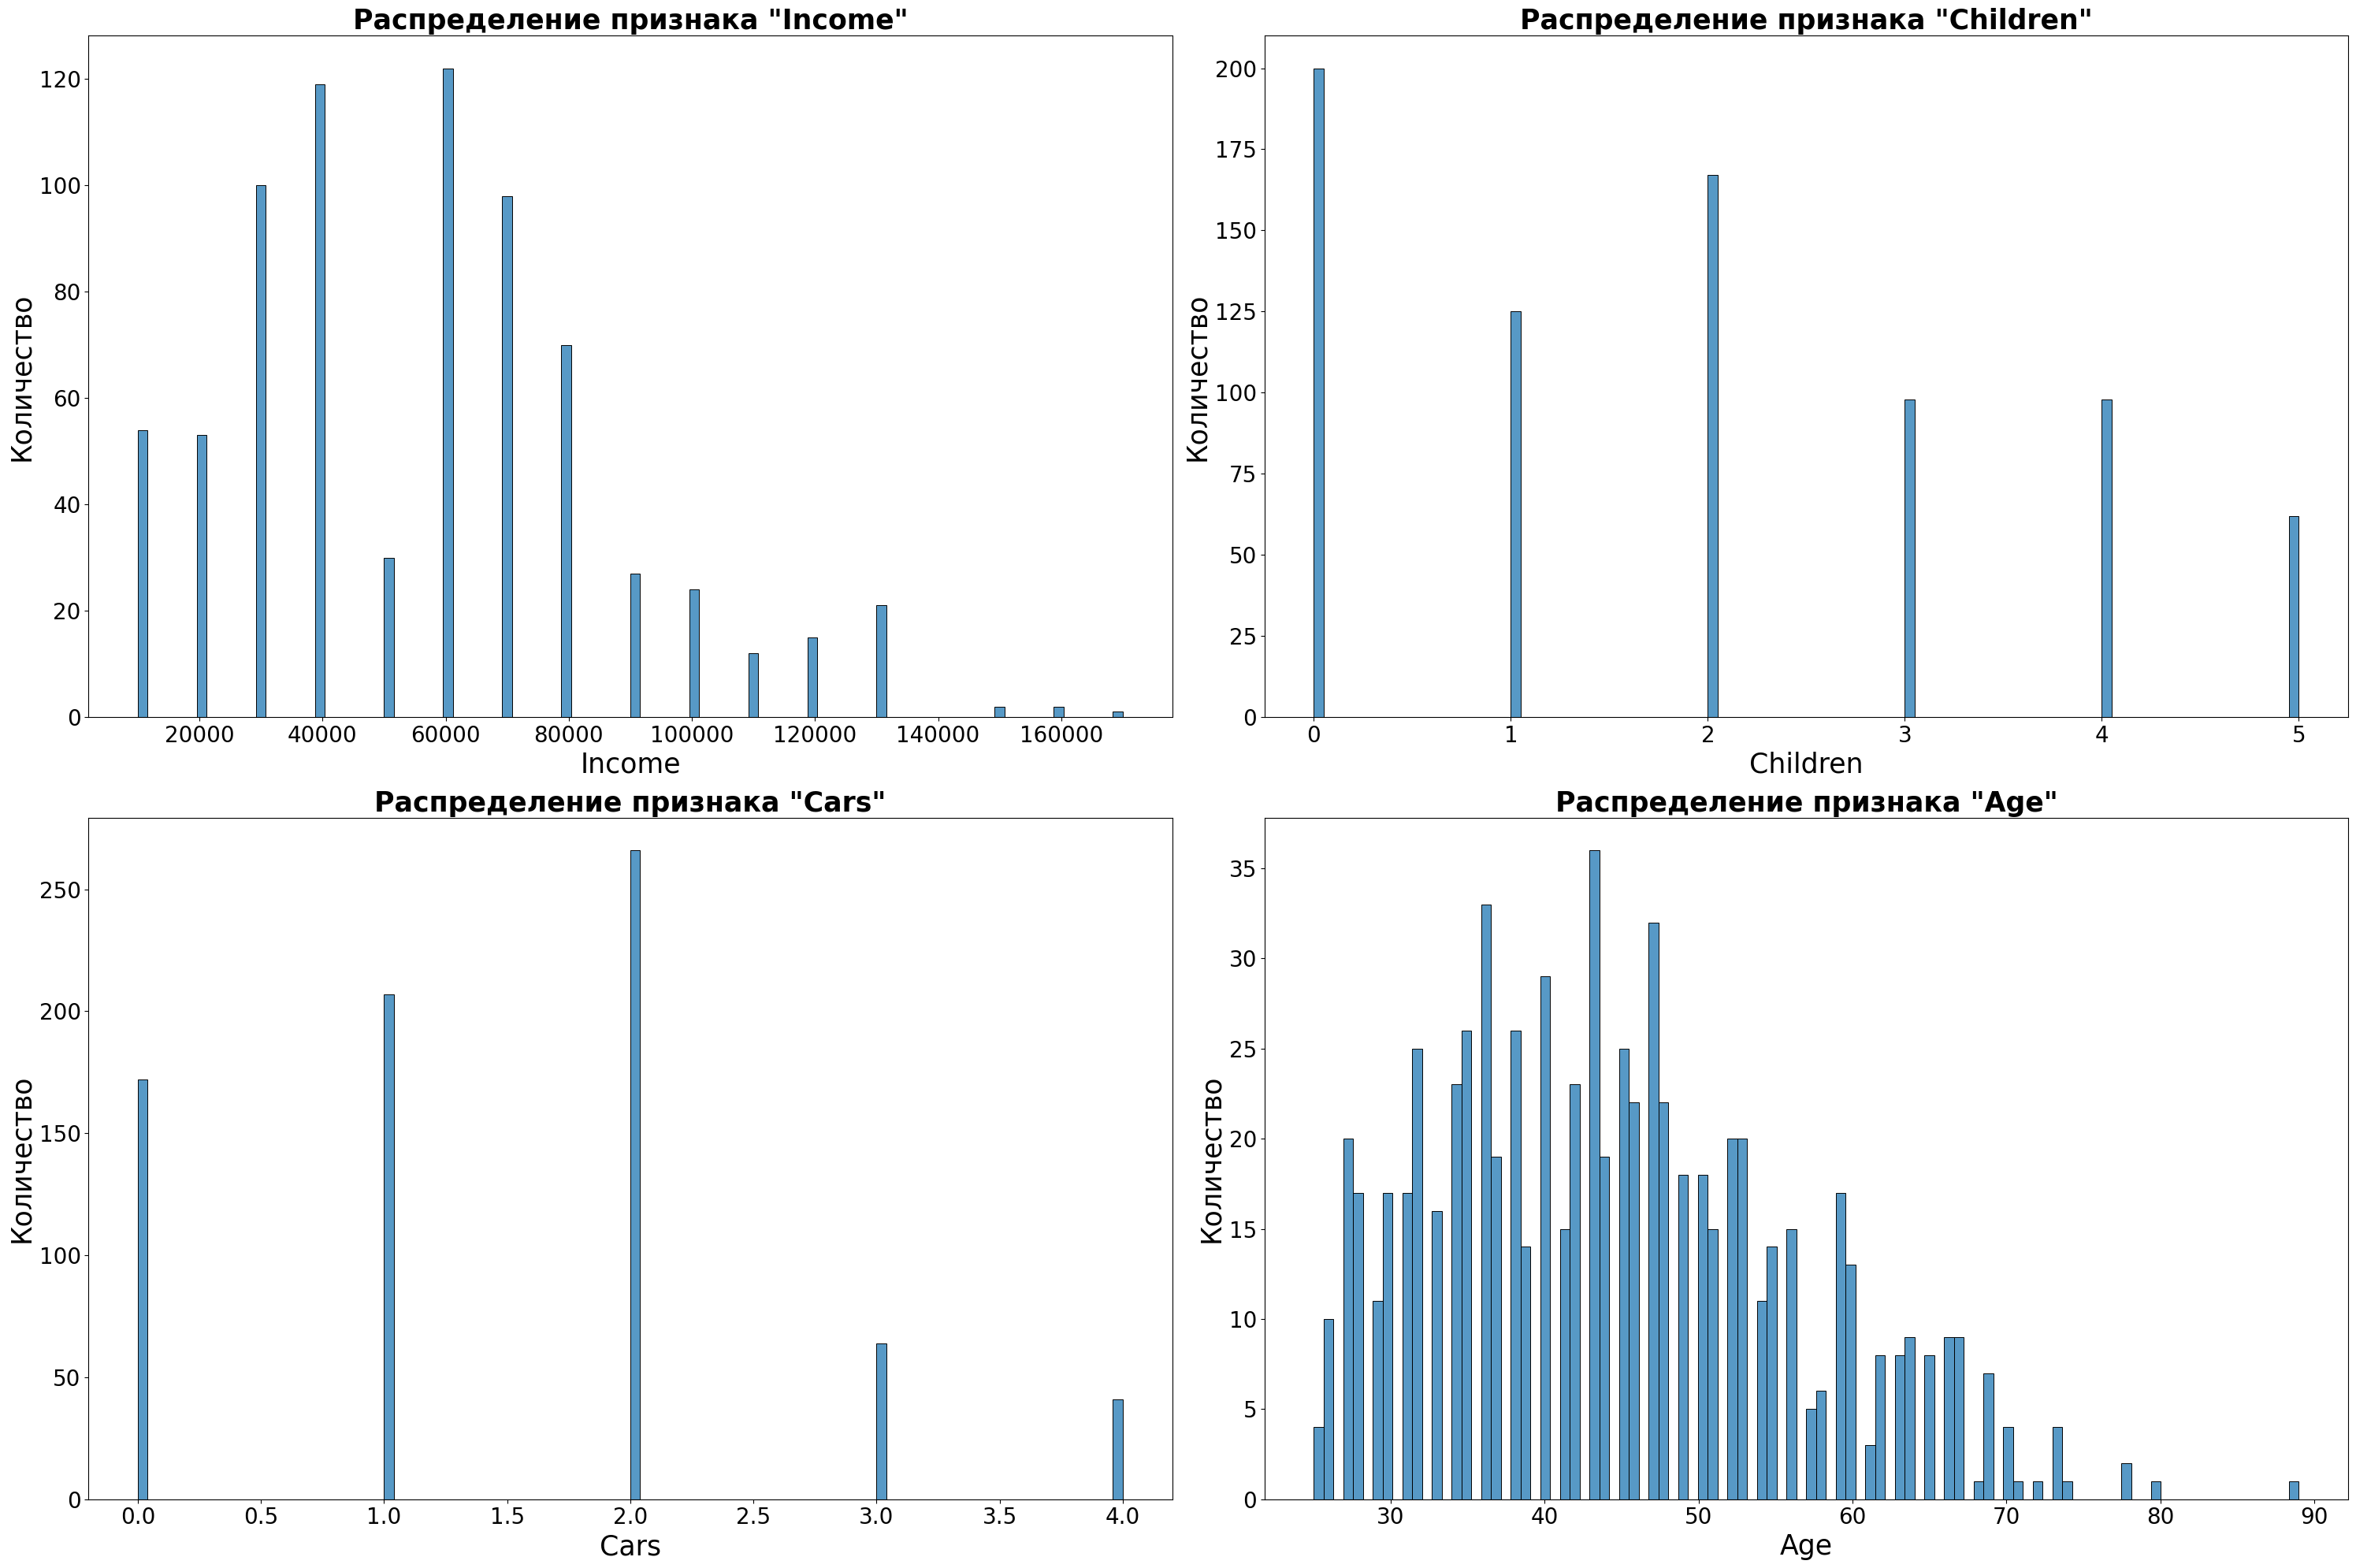

In [ ]:
from matplotlib import gridspec
import itertools
fig = plt.figure(figsize = (30, 20))
gr = gridspec.GridSpec(2, 2)
features = X_train_num.columns
for feature, grd in zip(features, itertools.product([0, 1], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.histplot(X_train_num[feature], bins=100)
    ax.tick_params(labelsize=20)
    ax.set_title(f'Распределение признака "{feature}"', fontsize = 25, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 25)
    ax.set_ylabel('Количество', fontsize = 25)
fig.tight_layout()
plt.show()

В данном случае видно, что присутствуют выбросы в переменных доход и возраст, причем распределения скошены вправо. Также переменные Cars и Children целочисленные, и их распределения тоже немного скошены, поэтому, тк среднее завышается из-за выбросов и скорее всего будет нецелым числом, лучше использовать медиану.

In [ ]:
X_train_num.median()

,0
Income,60000.0
Children,2.0
Cars,1.0
Age,43.0


In [ ]:
X_train_num = X_train_num.fillna(X_train_num.median())
X_test_num = X_test_num.fillna(X_train_num.median())

 Сейчас для числовых признаков мы ищем линейную зависимость, что в общем случае  может быть неверной гипотезой. Тем не менее, у этих признаков есть довольно много уникальных значений (сколько?), поэтому применять к ним one-hot кодирование может оказаться излишним. Попробуйте закодировать эти признаки с помощью счетчиков. Стало ли лучше?

In [ ]:
X_train_num.nunique() # количество уникальных значений каждого признака в трейне

,0
Income,16
Children,6
Cars,5
Age,53


In [ ]:
# использую библиотечный encoder, так как не сказано, что нельзя :)))
from sklearn.preprocessing import TargetEncoder
targ_enc = TargetEncoder()
X_train_num_enc = pd.DataFrame(targ_enc.fit_transform(X_train_num, y_train), columns=targ_enc.get_feature_names_out())
X_test_num_enc = pd.DataFrame(targ_enc.transform(X_test_num), columns=targ_enc.get_feature_names_out())

In [ ]:
X_train_bikes = pd.concat((X_train_MTE3.reset_index(drop=True), X_train_num_enc), axis=1)
X_test_bikes = pd.concat((X_test_MTE3.reset_index(drop=True), X_test_num_enc), axis=1)

In [ ]:
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
logreg = LogisticRegression()
logreg.fit(X_train_bikes, y_train)

pred_proba = logreg.predict_proba(X_test_bikes)[:, 1]
auc_pr = average_precision_score(y_test, pred_proba)
print(f'AUC-PR: {auc_pr}')

AUC-PR: 0.7004352331446159


Стало лучше, потому что мы теперь учитываем больше признаков, которые могут влиять на целевую переменную.

> __Замечание.__ Усложнение методов вычисления счётчиков не делают результаты модели гарантированно лучше. Особенно с учётом того, что логистическая регрессия не такая сложная модель, чтобы переобучаться. Поэтому вы необязательно должны были получать на каждом шаге всё лучшие и лучшие результаты (но необходимые результаты у вас должны были получиться).



Как мы могли пронаблюдать, счётчики являются конкурентной альтернативой one-hot-кодированию. Опишите, какие плюсы и минусы использования счётчиков по сравнению с one-hot-кодированием вы заметили.

__Ответ:__ Плюсы: занимает гораздо меньше памяти; если правильно работать с переобучением, то счетчики лучше обобщают данные (смотрят не только на индикатор данной категории, но и на статистическую связь с таргетом).

Минусы: тот факт, что информация о таргете попадает в другие признаки, может привести к переобучению; может плохо работать, если в каждой категории признаков мало наблюдений.

# Часть 3. Отбор признаков (2 балла)

Загрузим данные [UCI Adult Dataset](https://archive.ics.uci.edu/ml/datasets/Adult). Этот набор данных содержит информацию о годовых доходах отдельных людей. В качестве признакового описания используется различная информация о человеке (образование, профессия, брачный статус и т.д.). Целевая переменная является бинарной: больше ли годовой доход 50K долларов или нет.

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data

--2024-11-28 10:08:24--  https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘adult.data’

adult.data              [ <=>                ]   3.79M  --.-KB/s    in 0.08s   

2024-11-28 10:08:24 (45.6 MB/s) - ‘adult.data’ saved [3974305]



In [ ]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
    'income'
]

df = pd.read_csv('adult.data', header=None, names=columns)
df['income'] = (df['income'] != " <=50K").astype('int32')
df.sample()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
13881,38,Private,210866,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,44,United-States,1


Важной частью процесса построения модели является отбор признаков. На практике многие признаки оказывают малое влияние на модель (при этом их расчёт занимает время) или даже негативно сказываются на качестве модели. Попробуем несколько подходов отбора признаков, оценим, как они влияют на качество модели и сколько времени занимают.



Разделите выборку на обучающую и тестовую в соотношении 3:1. Зафиксируйте `random_state=777`, также используйте `stratify=True`.

In [ ]:
y = df['income']
X = df.drop(columns='income')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=777, stratify=y)

Давайте закодируем все категориальные признаки с помощью One-hot Encoding. Сколько новых признаков мы получим?

In [ ]:
cat = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
ohe = OneHotEncoder(handle_unknown='ignore')

X_train_cat = pd.DataFrame(ohe.fit_transform(X_train[cat]).toarray(), columns=ohe.get_feature_names_out())
X_test_cat = pd.DataFrame(ohe.transform(X_test[cat]).toarray(), columns=ohe.get_feature_names_out())

In [ ]:
X_train_ohe = pd.concat((X_train.drop(columns=cat).reset_index(drop=True), X_train_cat), axis=1)
X_test_ohe = pd.concat((X_test.drop(columns=cat).reset_index(drop=True), X_test_cat), axis=1)

In [ ]:
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
print(f'Было признаков {X_train.shape[1]}, стало {X_train_ohe.shape[1]}')

Было признаков 14, стало 108


В качестве основной модели будем использовать логистическую регрессию, а целевой метрики — `AUC-PR`. Обучите модель и посчитайте качество на тестовой выборке. Давайте запомним полученное значение.

In [ ]:
logreg = LogisticRegression(max_iter=10 ** 5)
logreg.fit(X_train_ohe, y_train)
y_pred = logreg.predict_proba(X_test_ohe)[:, 1]
auc_pr = average_precision_score(y_test, y_pred)
print(f'AUC-PR on test = {auc_pr}')

AUC-PR on test = 0.7633245794026075


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Допустим, мы хотим оставить только 40 лучших признаков.

Заметим, что нельзя оценивать качество по тестовой выборке, иначе мы можем переобучиться, как, например, при настройке гиперпараметров. Разделите обучающую выборку на 2 части, одну из которых, используйте для валидации. Исходную тестовую выборку стоит использовать только для финальной оценки качества после процедуры фильтрации

In [ ]:
X_train2, X_val, y_train2, y_val = train_test_split(X_train_ohe, y_train, test_size=0.25, random_state=777, stratify=y_train)

Попробуем сделать это следующими способами:

#### __Задание 9. Встроенные методы (0.5 балла)__

Начнём с отбора признаков с помощью модели. У разных алгоритмов есть разные встроенные способы оценки вклада признаков в предсказание. Как известно, у линейной модели за это отвечают веса, а значит, их модуль можно интерпретировать как важность. Такой метод отбора называются встроенным или embedded method, так как он заложен в особенности модели.

Оставьте 40 признаков с наибольшим модулем соответствующего параметра линейной модели. Обучите модели заново и оцените её качество. Замерьте скорость такого отбора признаков.



In [ ]:
start_time = time.time()
index_feat = np.argsort(abs(logreg.coef_[0]))[-40:]
X_train2_cut = X_train2.loc[:, logreg.feature_names_in_[index_feat]]
X_val_cut = X_val.loc[:, logreg.feature_names_in_[index_feat]]

logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train2_cut, y_train2)
pred_proba = logreg.predict_proba(X_val_cut)[:, 1]

aucPR = average_precision_score(y_val, pred_proba)
time_emb = time.time() - start_time

print(f'Затраченное время {time_emb}')
print(f'AUC-PR {aucPR}')

Затраченное время 0.10780167579650879
AUC-PR 0.6630025096178691


Изменилось ли качество? Как?

Да, качество снизилось.

Подумаем, что мы не учли. Мы действовали в предположении, что признаки вносят вклад равномерно, и не учитывали их масштаб. Если мы умножим один из признаков в 100 раз, то без учёта регуляризации его вес уменьшится в эти же 100 раз. А мы на основе этого отбираем признаки! Давайте сначала отмасштабируем признаки одним из способов, а только потом будем удалять признаки.

Помните, что не все способы одинаково хороши, особенно в условиях наличия выбросов

Кстати, в таком случае надо пересчитать качество на всех признаках (сделайте это ниже). Если вы сделали нормирование признаков в самом начале, то попробуйте отобрать признаки на неотмасштабированных данных.

Что получилось?

In [ ]:
from sklearn.preprocessing import RobustScaler
numeric = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_ohe[numeric]), columns=scaler.get_feature_names_out())
X_test_scaled = pd.DataFrame(scaler.transform(X_test_ohe[numeric]), columns=scaler.get_feature_names_out())

In [ ]:
X_train_ = pd.concat((X_train_scaled, X_train_ohe.drop(columns=numeric)), axis=1)
X_test_ = pd.concat((X_test_scaled, X_test_ohe.drop(columns=numeric)), axis=1)

In [ ]:
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train_, y_train)
y_pred = logreg.predict_proba(X_test_)[:, 1]
auc_pr = average_precision_score(y_test, y_pred)
print(f'AUC-PR on test = {auc_pr}') # качество получилось лучше, и сходится быстрее

AUC-PR on test = 0.7670752055710099


Вопрос на засыпку: one-hot кодирование возвращает нам единичные признаки-индикаторы. Попробуйте также отскалировать их, как и обычные числовые, и снова выбрать 40 главных по вкладу признаков. Изменился ли их список? Изменится ли качество?

In [ ]:
scaler = RobustScaler()
X_train_cat_sc = pd.DataFrame(scaler.fit_transform(X_train_.drop(columns=numeric)), columns=scaler.get_feature_names_out())
X_test_cat_sc = pd.DataFrame(scaler.transform(X_test_.drop(columns=numeric)), columns=scaler.get_feature_names_out())

In [ ]:
X_train_all_scaled = pd.concat((X_train_[numeric], X_train_cat_sc), axis=1)
X_test_all_scaled = pd.concat((X_test_[numeric], X_test_cat_sc), axis=1)

In [ ]:
X_train3, X_val2, y_train3, y_val2 = train_test_split(X_train_all_scaled, y_train, test_size=0.25, random_state=777, stratify=y_train)

In [ ]:
indeces = np.argsort(abs(logreg.coef_[0]))[-40:]
X_train3_cut = X_train2.loc[:, logreg.feature_names_in_[indeces]]
X_val2_cut = X_val.loc[:, logreg.feature_names_in_[indeces]]

In [ ]:
print(f'Совпадают {np.isin(X_train2_cut.columns, X_train3_cut.columns).sum()} признаков из 40')

Совпадают 16 признаков из 40


In [ ]:
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train3_cut, y_train3)
pred_proba = logreg.predict_proba(X_val2_cut)[:, 1]
aucPR = average_precision_score(y_val2, pred_proba)

print(f'AUC-PR {aucPR}')

AUC-PR 0.6767663440392513


Качество увеличилось (по сравнению с прошлой моделью, где использовалось 40 признаков), однако оно все еще хуже обучения на всех признаках. Далее я не буду использовать нормализацию категориальных признаков, так как они итак не имеют проблем с масштабом (все принимают значения 0 и 1), кроме того теряется интерпретация (0 и 1 это метки отсутсвия и наличия данной категории, после нормализации меняются значения)

#### __Задание 10. Методы фильтрации (0.5 балла)__


Давайте отбирать признаки умнее, а именно через подсчёт некоторой функции для каждого признака. На основании значений этой функции будем оставлять наиболее важные признаки. Методы этого семейства называют фильтрующими или  filter methods.

Одна из самых простых функция - корреляция между признаком и целевой переменной. Подумайте, какая взаимосвязь между корреляцией и предсказательной способностью модели, и как бы вы использовали информацию о корреляции для отбора признаков

**Ответ:** корреляция - это мера линейной связи между двумя переменными, поэтому, если коэффициент корреляции между таргетом и признаком высока по модулю, то признак может быть линейно связан с целевой переменной и хорошо ее объяснять. Нужно брать признаки с более высокой по модулю корреляции.

Посчитайте корреляцию каждого признака с таргетом и отфильтруйте 40 признаков исходя из того, что вы описали, после чего замерьте качество и время отбора



In [ ]:
X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(X_train_, y_train, test_size=0.25, random_state=777, stratify=y_train)

In [ ]:
start_time = time.time()
corr_feat = abs(pd.concat((X_train_2, y_train), axis=1).corr()['income'].drop('income')).sort_values()[-40:].index
X_train_2_cut = X_train_2[corr_feat]
X_val_2_cut = X_val_2[corr_feat]

logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train_2_cut, y_train_2)
pred_proba = logreg.predict_proba(X_val_2_cut)[:, 1]

aucPR = average_precision_score(y_val_2, pred_proba)
time_emb = time.time() - start_time

print(f'Затраченное время {time_emb}')
print(f'AUC-PR {aucPR}')

Затраченное время 20.884027242660522
AUC-PR 0.7599470958265288


В качестве еще одной функция можно считать t-статистику:

$$t(j) = \frac{|\mu_+ - \mu_-|}{\sqrt{\frac{n_+ \sigma^2_+ + n_- \sigma^2_-}{n_+ + n_-}}},$$

где $\mu$, $\sigma$, $n$ соответственно среднее, стандартное отклонение и количество объектов каждого из классов.

Оставьте 40 признаков с наибольшим значением $t$, замерьте качество и скорость отбора признаков.

In [ ]:
start_time = time.time()
n_pos = X_train_2[y_train_2 == 1].sum()
n_neg = X_train_2[y_train_2 == 0].sum()

mu_pos = X_train_2[y_train_2 == 1].mean()
mu_neg = X_train_2[y_train_2 == 0].mean()

sigma_pos = X_train_2[y_train_2 == 1].std()
sigma_neg = X_train_2[y_train_2 == 0].std()

t_values = np.abs(mu_pos - mu_neg) / np.sqrt((n_pos * sigma_pos ** 2 + n_neg * sigma_neg ** 2) / (n_pos + n_neg))
in_feat_t = t_values.sort_values()[-40:].index

X_train_2_cut = X_train_2[in_feat_t]
X_val_2_cut = X_val_2[in_feat_t]

logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train_2_cut, y_train_2)
pred_proba = logreg.predict_proba(X_val_2_cut)[:, 1]

aucPR = average_precision_score(y_val_2, pred_proba)
time_emb = time.time() - start_time

print(f'Затраченное время {time_emb}')
print(f'AUC-PR {aucPR}') # осталось примерно на том же уровне

Затраченное время 16.37776279449463
AUC-PR 0.7598913292077669


# Часть 4. Оценка экономического эффекта модели (2 балла)



В данной части мы займемся тем, что от вас скорее всего потребуется на реальной работе (помимо перекладки `json`, разумеется). А именно:
- мы соберем несколько специализированных метрик качества,
- попытаемся настроить модель на максимизацию _прибыли_,
- оценим, сколько вообще получится заработать на этом.

Разумеется, здесь будет сделано множество упрощающих жизнь допущений, но обо всем по порядку. Если вы всё прослушали на экономике, то напомним, что выручка — это сколько денег нам принесли клиенты, а прибыль — выручка за вычетом расходов на зарплату и прочее.


#### __Задание 12. Прогноз по доходам и расходам__ (1 балл)

В этой части мы будем работать с данными [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/ml/datasets/bank+marketing). Этот датасет содержит информацию о банковском телефонном маркетинге.

__Объектом__ здесь является телефонный звонок потенциальному клиенту с предложением некоторой услуги (утверждается, что это краткосрочный депозит). В качестве признакового описания используются характеристики клиента (образование, брак и т.д.), данные о звонке и различные экономические индикаторы - более подробная информация представлена в файле `bank-additional-names.txt`.
__Целевая переменная__ - ответ клиента (согласился ли он открыть депозит?)

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
!unzip bank-additional.zip
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

--2024-11-28 17:17:01--  https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank-additional.zip’

bank-additional.zip     [ <=>                ] 434.15K  --.-KB/s    in 0.05s   

2024-11-28 17:17:01 (8.98 MB/s) - ‘bank-additional.zip’ saved [444572]

Archive:  bank-additional.zip
   creating: bank-additional/
  inflating: bank-additional/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/bank-additional/
  inflating: __MACOSX/bank-additional/._.DS_Store  
  inflating: bank-additional/.Rhistory  
  inflating: bank-additional/bank-additional-full.csv  
  inflating: bank-additional/bank-additional-names.txt  
  inflating: bank-additional/bank-additional.csv  
  inflating: __MACOSX/._bank-additional  


In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
X = df.drop(columns=['duration', 'y'])
y = (df.y == 'yes')

В этой части не нужно делить выборку - мы будем использовать кросс-валидацию.  Используйте наиболее подходящие с вашей точки зрения параметры и их значения (`shuffle`, `stratify`, число фолдов, ...). По кросс-валидации у вас получится несколько вариантов обучающей и тестовой выборки. Для удобства можно воспользоваться шаблоном ниже, который по ходу выполнения задания будет обрастать функционалом. Как обычно, это необязательно, но сохранять результаты экспериментов очень и очень желательно, в конце мы будем их сравнивать

In [ ]:
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

def cross_validate(
    X,
    y,
    model,
    params=1,
    n_splits=5,
    random_state=None,
    shuffle=False,
    metrics_include='all'):
    metrics = []
    # или любой другой фолд, посмотрите в model_selection
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    for param in tqdm(params):
        model.set_params(C=param)
        profit_list, auc_pr_list, revenue_list = [], [], []
        for train_index, test_index in kf.split(X):

            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y.iloc[train_index], y[test_index]
            categorical = X_train.select_dtypes(['object']).columns
            numeric = X_train.select_dtypes(['int64', 'float64']).columns
            column_transformer = ColumnTransformer([
                ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
                ('scaling', StandardScaler(), numeric)
                ], verbose_feature_names_out=False)

            column_transformer.fit(X_train)
            X_train_ = pd.DataFrame(column_transformer.transform(X_train), columns=column_transformer.get_feature_names_out())
            X_test_ = pd.DataFrame(column_transformer.transform(X_test), columns=column_transformer.get_feature_names_out())
            y_train = y_train.reset_index(drop=True)
            y_test = y_test.reset_index(drop=True)

            model.fit(X_train_, y_train)
            y_pred = model.predict(X_test_)
            y_pred_proba = model.predict_proba(X_test_)[:, 1]

            revenue = ((y_test == y_pred) & (y_pred == 1)).sum() * 10
            costs = (y_pred == 1).sum() * 2
            profit = revenue - costs

            random_rev = np.random.uniform(0, 20, ((y_test == y_pred) & (y_pred == 1)).sum())
            random_prof = random_rev.sum() - costs
            # посчитайте метрики, которые вам нужны и добавьте результаты с каждого фолда
            if len(params) == 1:
                metric_dict = {
                    'AUC-PR': average_precision_score(y_test, y_pred_proba),
                    'revenue': revenue,
                    'profit': profit,
                    'revenue_rand': random_rev.sum(),
                    'profit_rand': random_prof
                }
                metrics.append(metric_dict)

            profit_list.append(random_prof)
            auc_pr_list.append(average_precision_score(y_test, y_pred_proba))
            revenue_list.append(random_rev.sum())

        if len(params) != 1:
            metric_dict = {
                    'profit_mean': np.mean(profit_list),
                    'revenue_mean': np.mean(revenue_list),
                    'AUC-PR_mean': np.mean(auc_pr_list)
                }
            metrics.append(metric_dict)

    if metrics_include == 'all':
        df_metrics = pd.DataFrame(metrics)
    else:
        df_metrics = df_metrics[metrics_include]
    # осталось только красиво всё обернуть
    return df_metrics

Выберите метрику классификации, которая вам кажется подходящей, и обучите логистическую регрессию на каждой обучающей выборке (закодируйте категориальные признаки способом, который выше вам понравился больше всех, отнормируйте числовые, гиперпараметры оставьте по умолчанию), сделайте предсказания для соответствующих тестовых выборок, выведите результаты

In [ ]:
cross_validate(X, y, LogisticRegression(), random_state=42, shuffle=True, metrics_include='AUC-PR')

,AUC-PR
0,0.430556
1,0.472721
2,0.449833
3,0.454738
4,0.455881


Допустим, работники вашего колл-центра получают за один звонок клиенту 2 доллара. При согласии клиента на предлагаемые условия он принесет в банк 10 долларов. Предположим, что всем положительным прогнозам ваши сотрудники решили позвонить.

В качестве бизнес-метрики в нашей задаче мы будем считать прибыль aka `profit`, соответственно лучшую модель будем выбирать исходя из этого.
Посчитайте на всех тестовых выборках выручку и сохраните результаты для бизнес-метрики вместе с предыдущей метрикой, которую вы выбрали

Ответьте на вопросы:
- Сколько денег вы в среднем заработаете?
- Какое получилось стандартное отклонение профита?
- Сколько из заработанных денег придётся отдать операторам вашего колл-центра?
- Пропорциональна ли бизнес-метрика выбранной метрике классификации?

In [ ]:
metr_business = cross_validate(X, y, LogisticRegression(), random_state=42, shuffle=True, metrics_include=['AUC-PR', 'revenue', 'profit'])

In [ ]:
metr_business

,AUC-PR,revenue,profit
0,0.430556,1970,1356
1,0.472721,2190,1550
2,0.449833,2380,1652
3,0.454738,2030,1418
4,0.455881,2060,1454


In [ ]:
mean_profit = metr_business['profit'].mean()
std_profit = metr_business['profit'].std()
mean_costs = metr_business['revenue'].mean() - mean_profit
print(f'Средняя прибыль составляет {mean_profit}$')
print(f'Стандартное отклонение профита {std_profit}')
print(f'Издержки на операторов колл-центра составляют {mean_costs}$')

Средняя прибыль составляет 1486.0$
Стандартное отклонение профита 116.40446726822816
Издержки на операторов колл-центра составляю 640.0$


In [ ]:
metr_business[['profit', 'AUC-PR']].corr()

,profit,AUC-PR
profit,1.000000,0.489363
AUC-PR,0.489363,1.000000


AUC-PR в целом пропорциональна профиту, чем больше профит, тем больше метрика (за исключением 3 по счету строчки), коэффициент корреляции говорит о средней связи.

Внесем некоторую долю случайности. Пусть теперь согласный на условия клиент будет приносить не 10 долларов, а случайную величину, равномерно распределенную в интервале $[0;20)$. Проделайте все те же самые действия. Для имитации реальной ситуации **НЕ** фиксируйте `random_seed` при подсчете выручки с клиента (для разбиения на фолды разумеется оставьте). Что получилось?

In [ ]:
metrics_rand = cross_validate(X, y, LogisticRegression(), random_state=42, shuffle=True, metrics_include=['AUC-PR', 'revenue_rand', 'profit_rand'])

In [ ]:
metrics_rand

,AUC-PR,revenue_rand,profit_rand
0,0.430556,2007.439649,1393.439649
1,0.472721,2206.577613,1566.577613
2,0.449833,2361.103017,1633.103017
3,0.454738,2121.514830,1509.514830
4,0.455881,1823.828881,1217.828881


In [ ]:
mean_profit_rand = metrics_rand['profit_rand'].mean()
std_profit_rand = metrics_rand['profit_rand'].std()
mean_costs_rand = metrics_rand['revenue_rand'].mean() - mean_profit_rand
print(f'Средняя прибыль составляет {mean_profit_rand}$')
print(f'Стандартное отклонение профита {std_profit_rand}')
print(f'Издержки на операторов колл-центра составляют {mean_costs_rand}$')

Средняя прибыль составляет 1464.0927978936952$
Стандартное отклонение профита 163.3772755041636
Издержки на операторов колл-центра составляют 640.0$


Средняя прибыль немного снизилась, а стандартное отклонение увеличилось (из-за рандома), издержки, понятно, остались те же, но в целом в данной генерации не сильно изменилась ситуация, так как матожидание выручки равно 10.

Настройте по кросс-валидации коэффициент регуляризации модели для максимизации прибыли (считайте как случайную величину выше). Удалось ли получить какой-то выигрыш? При каком коэффициенте регуляризациии прибыль максимальна? Постройте график зависимости ожидаемой прибыли от коэффициента

In [ ]:
params = np.logspace(-3, 3, 30)
metr_c = cross_validate(X, y, LogisticRegression(), random_state=42, shuffle=True, params=params)

100%|██████████| 30/30 [01:27<00:00,  2.92s/it]


In [ ]:
metr_c['C-value'] = params
metr_c.loc[metr_c['profit_mean'].max() == metr_c['profit_mean'], ['C-value', 'profit_mean']] # макисмальная прибыль и лучшее С

,C-value,profit_mean
26,239.502662,1571.633583


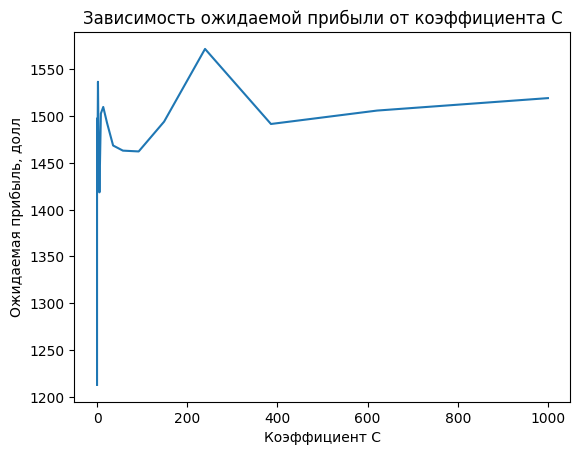

In [ ]:
plt.plot(metr_c['C-value'], metr_c['profit_mean'])
plt.title('Зависимость ожидаемой прибыли от коэффициента C')
plt.xlabel('Коэффициент С')
plt.ylabel('Ожидаемая прибыль, долл');

Попробуйте запустить перебор несколько раз. Находится ли каждый раз один и тот же "лучший" коэффициент? Присутствует ли какая-то закономерность? Какие вы можете сделать из этого выводы?

In [ ]:
params = np.logspace(-3, 3, 30)
metr_c = cross_validate(X, y, LogisticRegression(), random_state=42, shuffle=True, params=params)
metr_c['C-value'] = params
metr_c.loc[metr_c['profit_mean'].max() == metr_c['profit_mean'], ['C-value', 'profit_mean']] # макисмальная прибыль и лучшее С

100%|██████████| 30/30 [01:27<00:00,  2.90s/it]


,C-value,profit_mean
27,385.662042,1570.237457


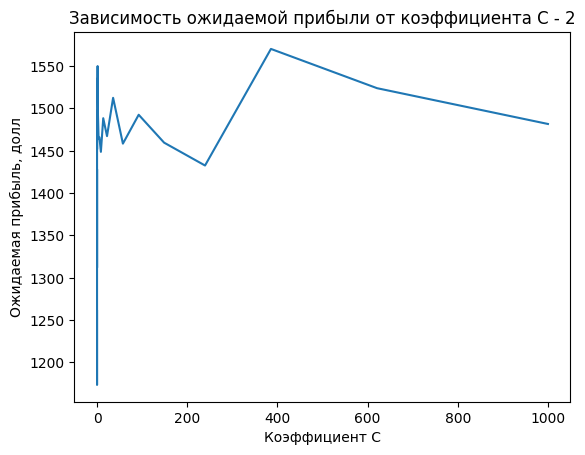

In [ ]:
plt.plot(metr_c['C-value'], metr_c['profit_mean'])
plt.title('Зависимость ожидаемой прибыли от коэффициента C - 2')
plt.xlabel('Коэффициент С')
plt.ylabel('Ожидаемая прибыль, долл');

In [ ]:
params = np.logspace(-3, 3, 30)
metr_c = cross_validate(X, y, LogisticRegression(), random_state=42, shuffle=True, params=params)
metr_c['C-value'] = params
metr_c.loc[metr_c['profit_mean'].max() == metr_c['profit_mean'], ['C-value', 'profit_mean']] # макисмальная прибыль и лучшее С

100%|██████████| 30/30 [01:26<00:00,  2.90s/it]


,C-value,profit_mean
8,0.045204,1581.348012


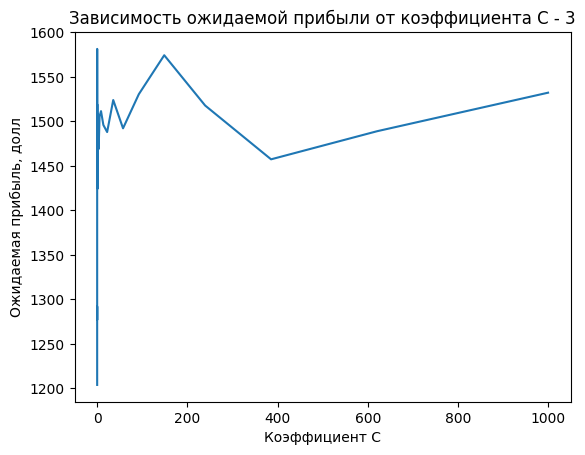

In [ ]:
plt.plot(metr_c['C-value'], metr_c['profit_mean'])
plt.title('Зависимость ожидаемой прибыли от коэффициента C - 3')
plt.xlabel('Коэффициент С')
plt.ylabel('Ожидаемая прибыль, долл');

In [ ]:
params = np.logspace(-3, 3, 30)
metr_c = cross_validate(X, y, LogisticRegression(), random_state=42, shuffle=True, params=params)
metr_c['C-value'] = params
metr_c.loc[metr_c['profit_mean'].max() == metr_c['profit_mean'], ['C-value', 'profit_mean']] # макисмальная прибыль и лучшее С

100%|██████████| 30/30 [01:25<00:00,  2.86s/it]


,C-value,profit_mean
24,92.367086,1586.53702


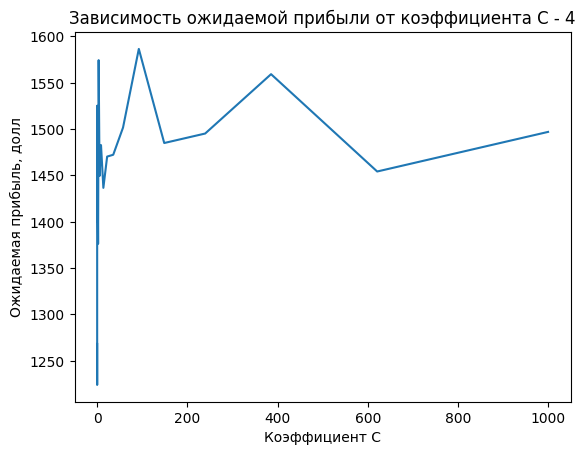

In [ ]:
plt.plot(metr_c['C-value'], metr_c['profit_mean'])
plt.title('Зависимость ожидаемой прибыли от коэффициента C - 4')
plt.xlabel('Коэффициент С')
plt.ylabel('Ожидаемая прибыль, долл');

Каждый раз коэффициенты разные, так как присутствует случайность в прибыли (при одном и том же коэффициенте прибыль может быть и максимальная, и нет, если запускать код несколько раз). Но, судя по графикам, тренд примерно одинаковый: при маленьких значениях профит низкий, скорее всего слишком сильный штраф за переобучение, если снизить регуляризацию, профит возрастает, а потом рандомно то ниже то выше. Возможно, модель должна быть достаточно сложной, чтобы правильно предсказывать классы, поэтому регуляризация здесь может мешать